In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
from kspecdr.io.image import ImageFile
import astroscrappy
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

WD = Path.home() / "Research/kspec/kspecdr"
RESOURCES = WD / "resources"
TESTDIR = RESOURCES / "comm" / "20260129"
CALDIR = TESTDIR / "calib"
CALCONVDIR = CALDIR / "converted"
CONVDIR = TESTDIR / "converted"
PROCDIR = TESTDIR / "processed"
ASSIGNDIR = RESOURCES / "comm" / "assign"

CALCONVDIR.mkdir(exist_ok=True)
CONVDIR.mkdir(exist_ok=True)
PROCDIR.mkdir(exist_ok=True)

mdark_path = RESOURCES / "comm" / "20260130" / "calib" / "mdark_2400s.fits"

In [4]:
fname = CONVDIR / "ctile_059 2026 January 29 17_28_46 1_im.fits"

hdul = fits.open(fname)

hdul.info()

Filename: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_im.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     155   (1340, 1300)   float32   
  1  VARIANCE      1 ImageHDU         8   (1340, 1300)   float32   
  2  FIBRES        1 BinTableHDU     27   14R x 9C   [K, D, D, D, D, D, K, 1A, 5A]   


In [5]:
default_params = {
    "sigclip": 4.5,
    "sigfrac": 0.3,
    "objlim": 5.0,
    "gain": None,
    "readnoise": None,
    "satlevel": 65535,
    # "satlevel": np.inf,
    "verbose": False,
}

# Update with any provided kwargs
params = default_params.copy()

sub1 = 0
sub2 = -1

# If gain/readnoise not set, try to read from header (RO_GAIN, RO_NOISE)
with ImageFile(fname) as im_file:
    readnoise = im_file.get_header_value("RO_NOISE")
    gain = im_file.get_header_value("RO_GAIN")
    image_data = im_file.read_image_data()[sub1:sub2, sub1:sub2]
    variance_data = im_file.read_variance_data()[sub1:sub2, sub1:sub2]


2026-03-04 23:14:23,534 | kspecdr.io.image | INFO | Opened file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_im.fits (mode: READ)
2026-03-04 23:14:23,552 | kspecdr.io.image | INFO | Closed file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_im.fits


In [6]:

print("Running LACosmic cosmic ray removal with astroscrappy")
print(f"Parameters: {params}")

# Run astroscrappy.detect_cosmics
# This returns (mask, cleaned_data)
mask, cleaned_data = astroscrappy.detect_cosmics(
    image_data,
    invar=variance_data,
    sigclip=params["sigclip"],
    sigfrac=params["sigfrac"],
    objlim=params["objlim"],
    gain=gain,
    readnoise=readnoise,
    satlevel=params["satlevel"],
    verbose=params["verbose"],
    sepmed=True,
)

# Count cosmic rays detected
n_cosmic = np.sum(mask)
print(f"Detected and removed {n_cosmic} cosmic ray pixels")

Running LACosmic cosmic ray removal with astroscrappy
Parameters: {'sigclip': 4.5, 'sigfrac': 0.3, 'objlim': 5.0, 'gain': None, 'readnoise': None, 'satlevel': 65535, 'verbose': False}
Detected and removed 6883 cosmic ray pixels


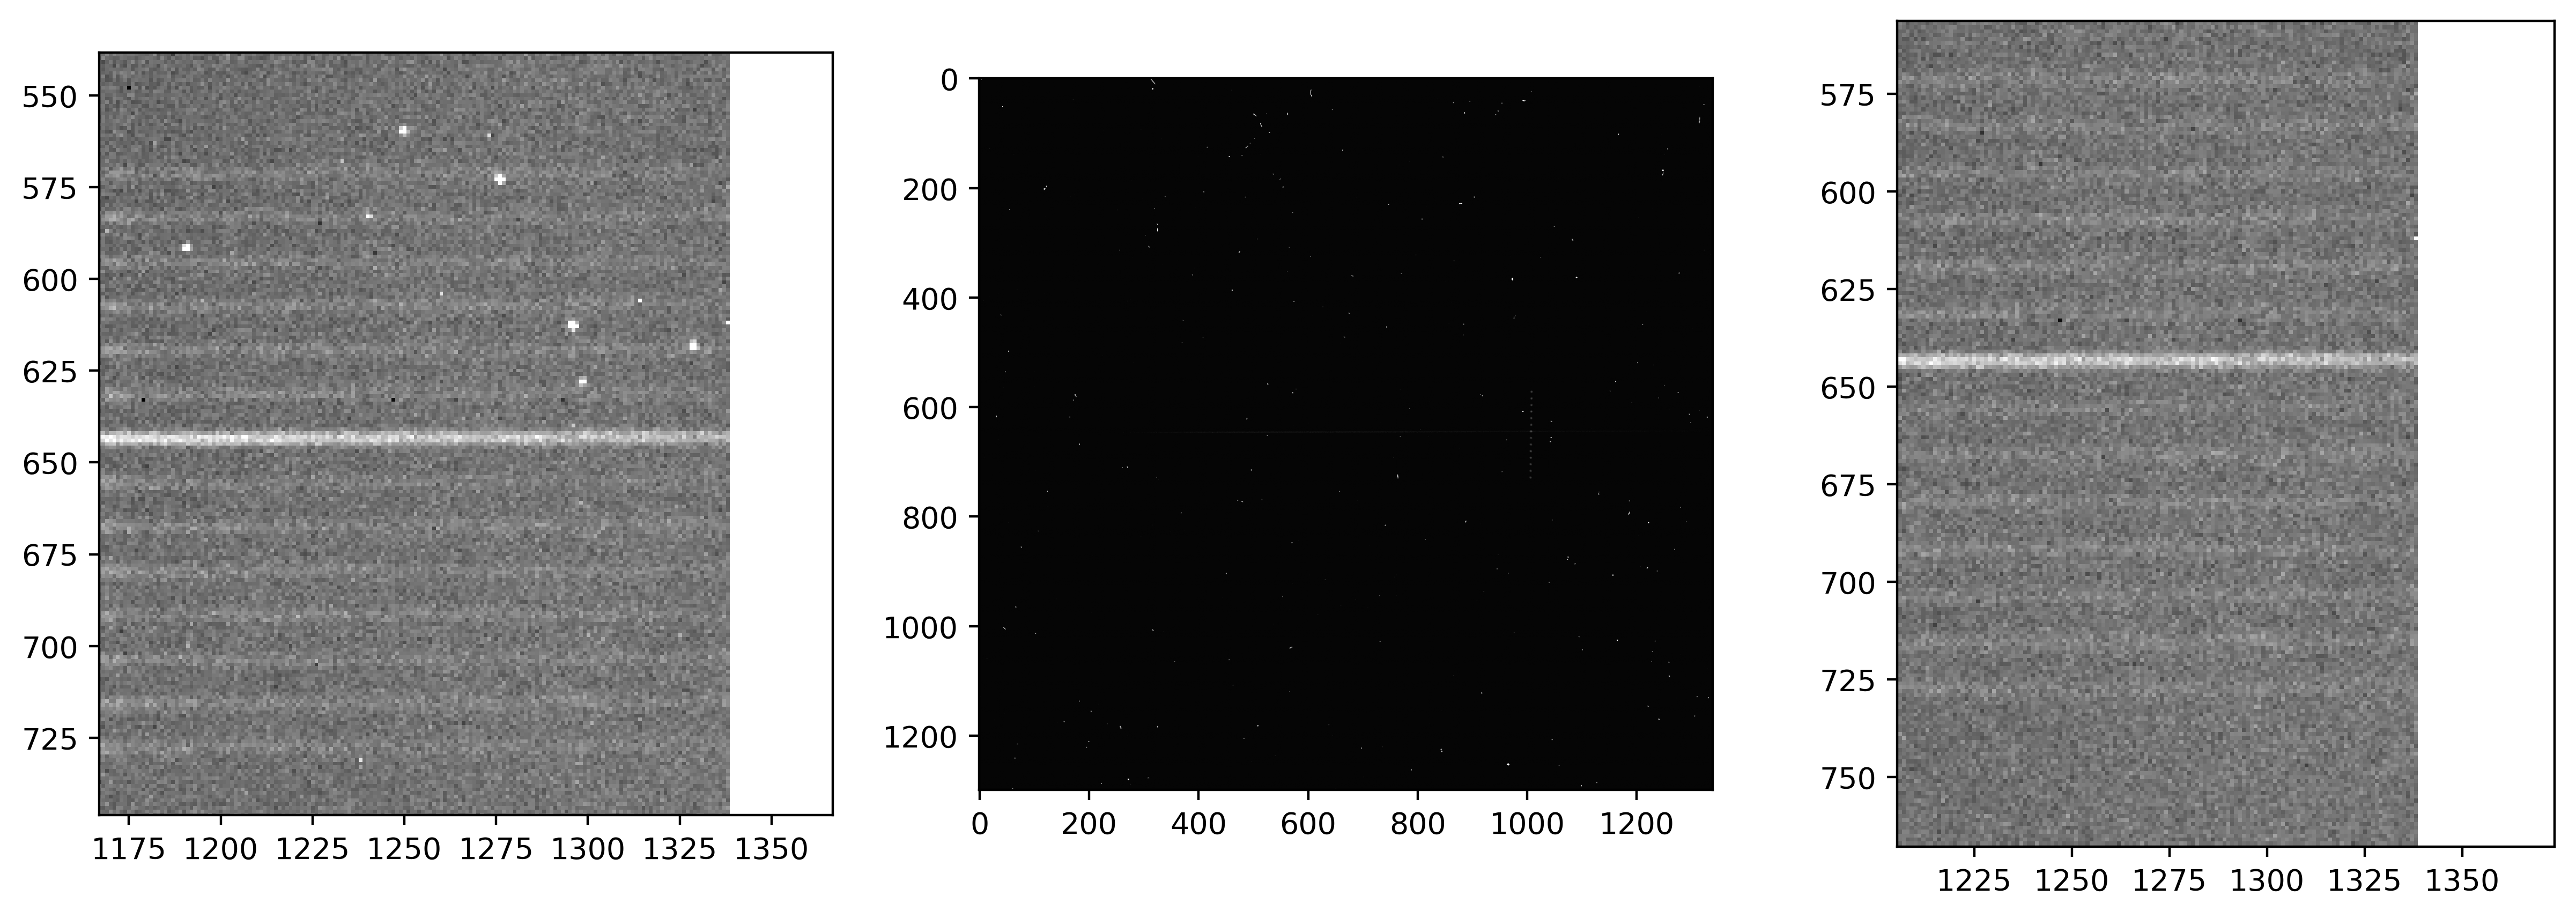

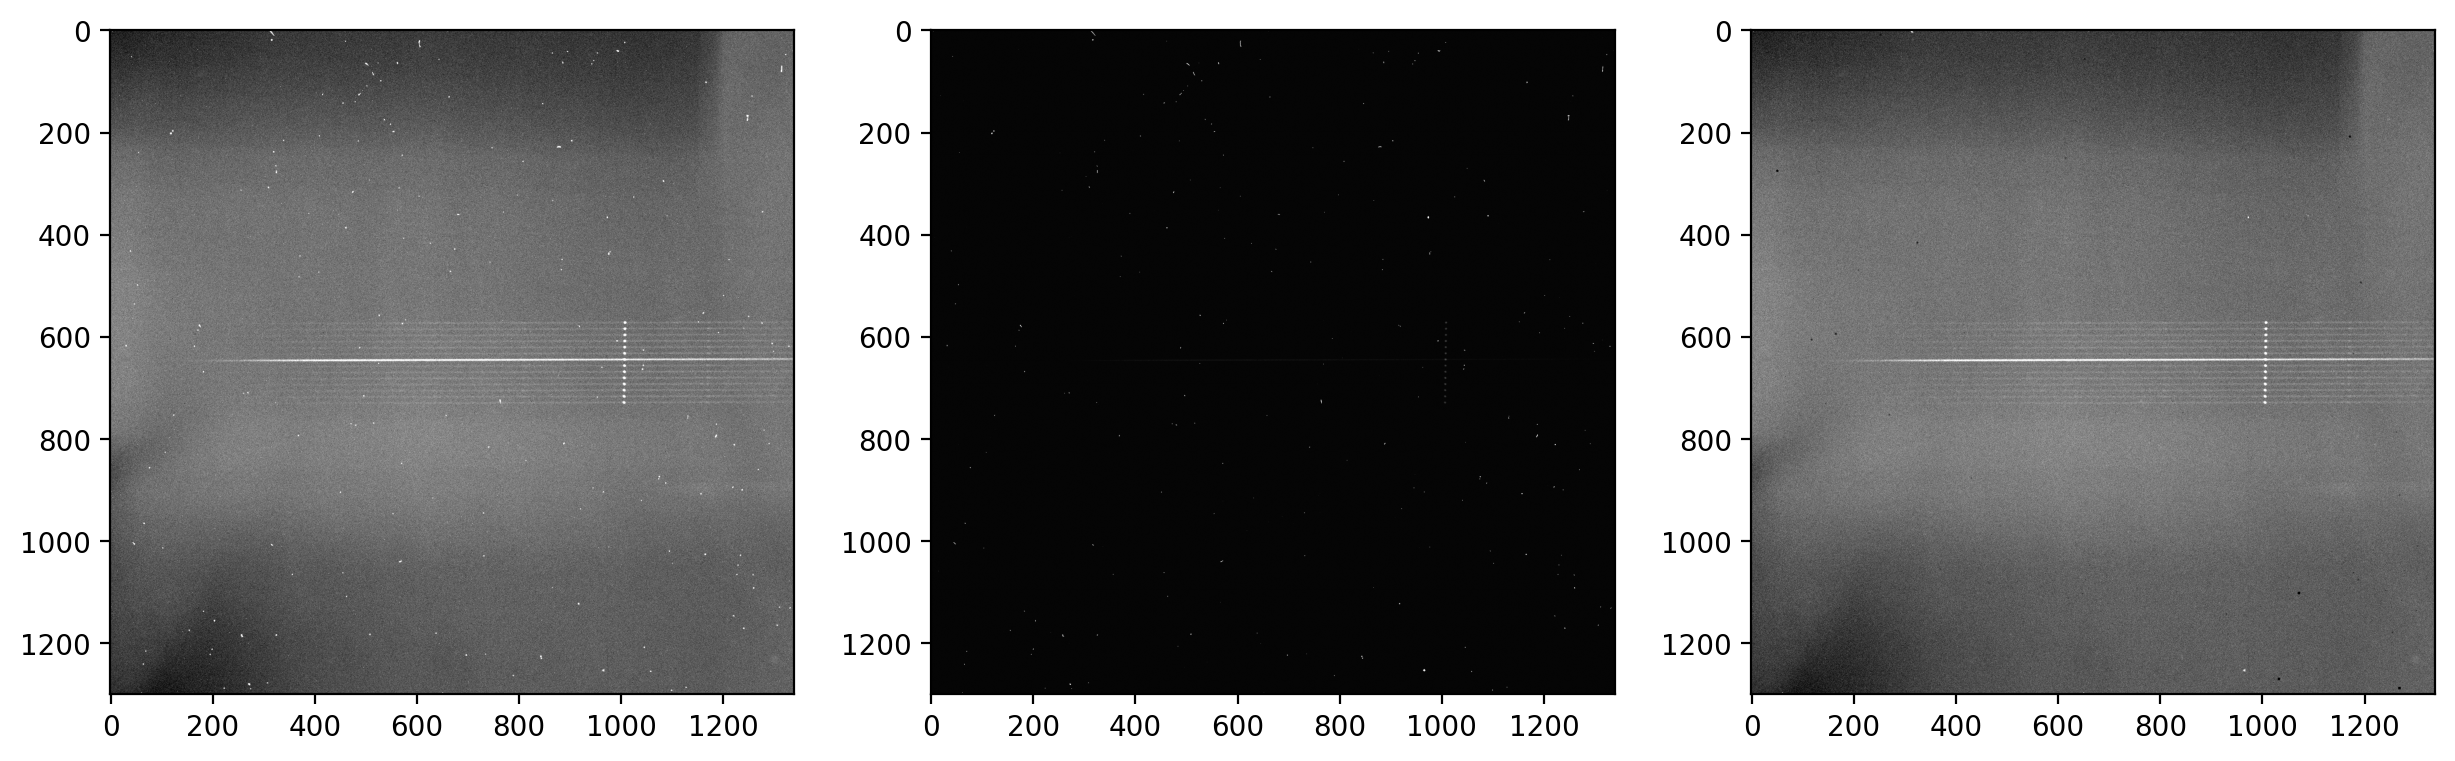

In [13]:
from astropy.visualization import ZScaleInterval

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image_data)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_data, cmap="gray", vmin=vmin, vmax=vmax)
ax[1].imshow(variance_data, cmap="gray", vmin=0, vmax=vmax**2)
ax[2].imshow(cleaned_data, cmap="gray", vmin=vmin, vmax=vmax)
plt.show()
